# 
La classe **GridEnv** permet de modéliser un **environnement sous forme de grille** utilisé dans les algorithmes de recherche de chemin (comme A*, Markov Decision Process, etc.).

Elle définit :
- la taille de la grille
- les obstacles
- les déplacements possibles
- le coût des mouvements

---

In [ ]:
import heapq
class GridEnv:
    def __init__(self, width, height, obstacles):
        self.width = width
        self.height = height
        self.obstacles = set(obstacles) 

    def is_in_bounds(self, id):
        (x, y) = id
        return 0 <= x < self.width and 0 <= y < self.height

    def is_passable(self, id):
        return id not in self.obstacles

    def get_neighbors(self, id):
        (x, y) = id
        # Déplacements : Haut, Droite, Bas, Gauche (4-voisins)
        results = [(x, y+1), (x+1, y), (x, y-1), (x-1, y)]
        # Filtrer les voisins en dehors de la grille ou sur des obstacles
        results = filter(self.is_in_bounds, results)
        results = filter(self.is_passable, results)
        return list(results)

    def cost(self, from_node, to_node):
        # Dans ce modèle simple, chaque déplacement coûte 1
        return 1

# Résumé des fonctions heuristiques

Les **fonctions heuristiques** permettent d'estimer la distance restante entre une position actuelle et l'objectif afin de **guider les algorithmes de recherche** vers la solution plus efficacement.

🔵 **Heuristique de Manhattan**  
Elle calcule la distance entre deux positions dans une grille en utilisant les déplacements horizontaux et verticaux.  
Cette heuristique est adaptée aux environnements où l’on se déplace uniquement dans **quatre directions** (haut, bas, gauche, droite).

🟢 **Greedy Best First Search**  
Cet algorithme utilise l’heuristique de Manhattan pour choisir **le nœud qui semble le plus proche du but**.  
Il permet souvent de trouver une solution rapidement, mais **le chemin obtenu n’est pas toujours optimal**.

🟠 **Uniform Cost Search (UCS)**  
Cet algorithme **n’utilise pas d’heuristique** et se base uniquement sur le **coût réel du chemin parcouru**.  
Il garantit de trouver **le chemin optimal**, mais peut être **plus lent** car il explore davantage d’états.

 **Conclusion :**  
Ces différentes heuristiques permettent de comparer plusieurs stratégies de recherche et d’analyser leur **efficacité, leur rapidité et leur optimalité** dans un environnement en grille.

In [ ]:

def manhattan_heuristic(a, b):
  
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def greedy_heuristic(a, b):
    return manhattan_heuristic(a, b)

def ucs_heuristic(a, b):
   
    return 0



#  l’algorithme A*

L’algorithme **A\*** est un algorithme de recherche de chemin utilisé pour trouver **le chemin optimal entre une position de départ et un objectif** dans un environnement donné (comme une grille).

Il combine deux informations importantes pour choisir le prochain nœud à explorer :

🔵 **Le coût réel du chemin parcouru (g(n))**  
Il représente la distance ou le coût total depuis la position de départ jusqu’au nœud actuel.

🟢 **L’estimation du coût restant (h(n))**  
Elle est calculée grâce à une **fonction heuristique** qui estime la distance entre le nœud actuel et l’objectif.

🟣 **La fonction d’évaluation (f(n))**  
L’algorithme utilise la formule suivante :

**f(n) = g(n) + h(n)**

Cette valeur permet de choisir **le nœud le plus prometteur à explorer**.

##  Fonctionnement général

1️⃣ L’algorithme commence par **ajouter le nœud de départ dans une liste de priorité**.  

2️⃣ À chaque étape, il **sélectionne le nœud ayant la plus petite valeur f(n)**.  

3️⃣ Il explore ensuite **les voisins accessibles de ce nœud**.  

4️⃣ Pour chaque voisin, il calcule le **coût total du chemin** et met à jour les informations si un chemin plus court est trouvé.  

5️⃣ Le processus continue jusqu’à ce que **l’objectif soit atteint**.


## Informations enregistrées pendant la recherche

Pendant l’exécution de l’algorithme, plusieurs informations sont stockées :

- **Le chemin parcouru** afin de reconstruire la route finale.
- **Le coût cumulé de chaque nœud** depuis le départ.
- **Le nombre de nœuds explorés**, utilisé pour mesurer la performance de l’algorithme.

 **Conclusion :**  
L’algorithme **A\*** est l’un des algorithmes de recherche les plus efficaces car il combine **le coût réel du chemin et une estimation intelligente de la distance restante**, ce qui lui permet de trouver **le chemin optimal tout en réduisant le nombre d’états explorés**.

In [70]:
# --- Phase 2: L'algorithme A* ---

def a_star_search(graph, start, goal, heuristic_func):
    open_list = []
    # heapq utilise le premier élément du tuple pour trier. 
    # Format : (f_cost, noeud_courant)
    heapq.heappush(open_list, (0, start))
    # Dictionnaires pour garder une trace des chemins (came_from) et des coûts g (cost_so_far)
    came_from = {start: None}
    cost_so_far = {start: 0}
    
    nodes_expanded = 0 # Pour vos mesures de performance

    while open_list:
        # Extraire le noeud avec le plus petit f(n)
        current_f, current = heapq.heappop(open_list)
        nodes_expanded += 1

        # Condition d'arrêt : on a atteint le but
        if current == goal:
            break
        
        # Explorer les voisins
        for next_node in graph.get_neighbors(current):
            # g(n) : Coût cumulé jusqu'au voisin
            new_cost = cost_so_far[current] + graph.cost(current, next_node)
            
            # Si on découvre un nouveau noeud ou un chemin moins coûteux vers un noeud connu
            if next_node not in cost_so_far or new_cost < cost_so_far[next_node]:
                cost_so_far[next_node] = new_cost
                # f(n) = g(n) + h(n)
                priority = new_cost + heuristic_func(next_node, goal)
                heapq.heappush(open_list, (priority, next_node))
                came_from[next_node] = current
                
    return came_from, cost_so_far, nodes_expanded


# Reconstruction du chemin
## Objectif
Cette fonction permet de **reconstruire le chemin final trouvé par l’algorithme de recherche** en utilisant les informations stockées dans **came_from**.

## Fonctionnement
La fonction commence par vérifier si un chemin vers l’objectif existe.  
Ensuite, elle **remonte depuis l’objectif jusqu’au point de départ** en suivant les nœuds précédents enregistrés.  
Comme le chemin est construit de l’objectif vers le départ, il est **inversé** afin d’obtenir l’ordre correct.

## Résultat
La fonction retourne **la liste des positions formant le chemin du départ vers l’objectif**.  
Si aucun chemin n’est trouvé, elle retourne **une liste vide**.

In [71]:
# Fonction utilitaire pour reconstruire le chemin depuis 'came_from'
def reconstruct_path(came_from, start, goal):
    if goal not in came_from:
        return [] # Pas de chemin trouvé
    
    current = goal
    path = []
    while current != start:
        path.append(current)
        current = came_from[current]
    path.append(start)
    path.reverse() # Inverser pour aller de 'start' à 'goal'
    return path

# Exécution du programme principal
##  Objectif
Cette partie du programme permet de **tester l’algorithme A\*** dans un environnement de grille afin de trouver un chemin entre un point de départ et un objectif.
## Fonctionnement
🔵 **Définition de l’environnement**  
Une grille de **5 × 5** est créée avec certaines cases définies comme **obstacles**, ce qui empêche l’agent de passer par ces positions.
🟢 **Définition du départ et de l’objectif**  
Une position de départ et une position d’arrivée sont choisies dans la grille afin de lancer la recherche du chemin.
🟣 **Exécution de l’algorithme A\***  
L’algorithme est exécuté en utilisant **l’heuristique de Manhattan** pour estimer la distance restante jusqu’au but.
🟠 **Reconstruction du chemin**  
Une fois la recherche terminée, le programme reconstruit **le chemin optimal entre le départ et l’objectif**.
## Résultats affichés
Le programme affiche ensuite :
- le **chemin trouvé** entre le départ et l’objectif
- le **coût total du chemin**
- le **nombre de nœuds explorés**, utilisé pour évaluer la performance de l’algorithme

In [72]:
if __name__ == "__main__":
    # Définition d'une petite grille 5x5
    # Les obstacles sont des coordonnées (x, y)
    obstacles = [(1, 1), (1, 2), (1, 3), (3, 1), (3, 2)]
    grid = GridEnv(width=5, height=5, obstacles=obstacles)
    
    start_node = (0, 2)
    goal_node = (4, 2)
    
    # Exécution de A*
    came_from, cost_so_far, expanded = a_star_search(grid, start_node, goal_node, manhattan_heuristic)
    path = reconstruct_path(came_from, start_node, goal_node)
    
    print(f"Chemin trouvé : {path}")
    print(f"Coût total g(n) : {cost_so_far.get(goal_node, 'Non atteint')}")
    print(f"Nombre de nœuds développés : {expanded}")

Chemin trouvé : [(0, 2), (0, 1), (0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2)]
Coût total g(n) : 8
Nombre de nœuds développés : 18


# Algorithme unifié et politique

- La fonction **run_search** permet d’exécuter **A\***, **UCS** ou **Greedy** avec le même code.  
- La priorité des nœuds dépend de l’algorithme choisi :  
  - A* → coût réel + heuristique  
  - UCS → coût réel  
  - Greedy → heuristique seule  
- Elle retourne le **chemin**, le **coût** et le **nombre de nœuds explorés**.

- La fonction **extract_policy** transforme ce chemin en **politique de navigation**, indiquant pour chaque position **la prochaine case à viser**.

In [73]:
# --- Mise à jour pour la Phase 2.2 : Un algorithme unifié ---

def run_search(graph, start, goal, algorithm="astar"):
    open_list = []
    heapq.heappush(open_list, (0, start))
    
    came_from = {start: None}
    cost_so_far = {start: 0}
    nodes_expanded = 0

    while open_list:
        _, current = heapq.heappop(open_list)
        nodes_expanded += 1

        if current == goal:
            break
        
        for next_node in graph.get_neighbors(current):
            new_cost = cost_so_far[current] + graph.cost(current, next_node)
            
            if next_node not in cost_so_far or new_cost < cost_so_far[next_node]:
                cost_so_far[next_node] = new_cost
                
                # C'est ici que la magie de la comparaison opère :
                h = manhattan_heuristic(next_node, goal)
                if algorithm == "astar":
                    priority = new_cost + h   # f(n) = g(n) + h(n)
                elif algorithm == "ucs":
                    priority = new_cost       # f(n) = g(n)
                elif algorithm == "greedy":
                    priority = h              # f(n) = h(n)
                    
                heapq.heappush(open_list, (priority, next_node))
                came_from[next_node] = current
                
    return came_from, cost_so_far, nodes_expanded

# --- Préparation Phase 3 : Extraction de la politique ---

def extract_policy(came_from, goal):
    """
    Transforme le chemin trouvé en une "politique" : 
    Pour un état donné, quelle est la case suivante à viser ?
    """
    policy = {}
    current = goal
    
    # On remonte du but vers le départ
    while current in came_from and came_from[current] is not None:
        previous = came_from[current]
        # La politique pour 'previous' est d'aller vers 'current'
        policy[previous] = current
        current = previous
        
    return policy
    

In [74]:
if __name__ == "__main__":
    # Reprenons notre grille 5x5 avec un mur au milieu
    obstacles = [(1, 1), (1, 2), (1, 3), (3, 1), (3, 2)]
    grid = GridEnv(width=5, height=5, obstacles=obstacles)
    start_node = (0, 2)
    goal_node = (4, 2)

    print(f"--- Comparaison sur la grille (Start: {start_node}, Goal: {goal_node}) ---")
    
    for algo in ["ucs", "greedy", "astar"]:
        came_from, costs, expanded = run_search(grid, start_node, goal_node, algorithm=algo)
        path = reconstruct_path(came_from, start_node, goal_node)
        
        # Le coût final est le g(n) du goal
        final_cost = costs.get(goal_node, float('inf')) 
        
        print(f"\nAlgorithme : {algo.upper()}")
        print(f"  Nœuds développés (mémoire/temps) : {expanded}")
        print(f"  Coût du chemin trouvé : {final_cost}")
    
    # On extrait la politique basée sur le meilleur résultat (A*)
    came_from_astar, _, _ = run_search(grid, start_node, goal_node, algorithm="astar")
    optimal_policy = extract_policy(came_from_astar, goal_node)
    
    print("\n--- Politique déterministe extraite (A*) ---")
    print(f"Depuis {start_node}, je dois aller vers {optimal_policy.get(start_node)}")

--- Comparaison sur la grille (Start: (0, 2), Goal: (4, 2)) ---

Algorithme : UCS
  Nœuds développés (mémoire/temps) : 20
  Coût du chemin trouvé : 8

Algorithme : GREEDY
  Nœuds développés (mémoire/temps) : 12
  Coût du chemin trouvé : 10

Algorithme : ASTAR
  Nœuds développés (mémoire/temps) : 18
  Coût du chemin trouvé : 8

--- Politique déterministe extraite (A*) ---
Depuis (0, 2), je dois aller vers (0, 1)


#  Phase 3 : Modélisation Markovienne

## Objectif
Cette phase transforme le **chemin trouvé par A\*** en un **processus de décision markovien stochastique**, afin de calculer la probabilité qu’un agent atteigne l’objectif en tenant compte des déviations possibles.


## Construction de la matrice stochastique (P)

1. **Identification des états valides** : toutes les cases libres de la grille.  
2. **Indexation des états** : chaque position (x, y) reçoit un index pour construire une matrice carrée.  
3. **Définition des probabilités de transition** :  
   - Action voulue → probabilité `1 - ε`  
   - Déviation latérale → probabilité `ε/2` pour chaque direction  
4. **Gestion des collisions** : si un mouvement mène à un obstacle ou en dehors de la grille, l’agent **reste sur place**.  
5. **Validation** : chaque ligne de la matrice P **somme à 1**, garantissant que la matrice est bien stochastique.


##  Calcul de l’évolution π(n)

- On initialise la distribution de départ π(0) : **100% de probabilité d’être à la position de départ**.  
- À chaque étape, la distribution évolue selon la formule **π(n) = π(n-1) × P**.  
- On peut observer **la probabilité d’être à l’objectif** à différents pas de temps, ce qui permet d’évaluer la **robustesse de la politique face aux déviations**.


## Résultat

- **P** : matrice de transition stochastique  
- **valid_states** : liste des états valides  
- **state_to_idx** : mapping état → index  
- **π(n)** : distribution des probabilités sur les états après n étapes

Cette approche permet d’analyser **la probabilité qu’un agent atteigne l’objectif malgré les incertitudes** dans ses mouvements.

In [84]:
import numpy as np

# --- Phase 3.1 & 3.2 : Construction de la matrice stochastique P ---

def build_markov_matrix(grid, policy, goal, epsilon=0.2):
    # 1. Identifier tous les états valides (cases libres)
    valid_states = []
    for x in range(grid.width):
        for y in range(grid.height):
            if grid.is_passable((x, y)):
                valid_states.append((x, y))
                
    # Créer un dictionnaire pour mapper chaque coordonnée (x, y) à un index entier i
    # (Indispensable pour créer une matrice classique)
    state_to_idx = {s: i for i, s in enumerate(valid_states)}
    n_states = len(valid_states)
    
    # Initialiser la matrice P avec des zéros
    P = np.zeros((n_states, n_states))
    
    for s in valid_states:
        i = state_to_idx[s]
        
        # Cas A : État absorbant GOAL
        if s == goal:
            P[i, i] = 1.0
            continue
            
        # Cas B : L'état n'a pas été exploré par A* (pas de politique)
        # Pour simplifier, on dit que l'agent reste bloqué sur place s'il s'y retrouve
        if s not in policy:
            P[i, i] = 1.0
            continue
            
        # Cas C : État normal avec une politique
        next_s = policy[s]
        dx = next_s[0] - s[0]
        dy = next_s[1] - s[1]
        
        # Définition des 3 mouvements possibles et de leurs probabilités
        # Vecteur orthogonal 1 : (-dy, dx) | Vecteur orthogonal 2 : (dy, -dx)
        moves = [
            ((dx, dy), 1 - epsilon),           # Action voulue
            ((-dy, dx), epsilon / 2.0),        # Déviation latérale 1
            ((dy, -dx), epsilon / 2.0)         # Déviation latérale 2
        ]
        
        for (mx, my), prob in moves:
            target_s = (s[0] + mx, s[1] + my)
            
            # Gestion des collisions : si on heurte un mur, on reste en 's'
            if not grid.is_in_bounds(target_s) or not grid.is_passable(target_s):
                target_idx = i # On reste sur place
            else:
                target_idx = state_to_idx[target_s]
                
            # On ajoute la probabilité (+= car plusieurs déviations peuvent mener à la même case)
            P[i, target_idx] += prob
            
    # Phase 3.2 : Vérification que P est stochastique (la somme de chaque ligne = 1)
    # np.allclose gère les petites erreurs d'arrondi des flottants
    assert np.allclose(P.sum(axis=1), 1.0), "Erreur: La matrice P n'est pas stochastique !"
    
    return P, valid_states, state_to_idx

# --- Phase 3.3 : Calcul de l'évolution π(n) ---

def calculate_markov_evolution(P, start_idx, goal_idx, steps):
    n_states = P.shape[0]
    
    # π(0) : On est sûr à 100% de démarrer au point s0
    pi = np.zeros(n_states)
    pi[start_idx] = 1.0
    
    print("\n--- Évolution des probabilités (Chapman-Kolmogorov) ---")
    for n in range(1, steps + 1):
        # Évolution : π(n) = π(n-1) * P
        pi = pi @ P 
        
        if n % 2 == 0 or n == steps: # Afficher un pas sur deux pour ne pas polluer la console
            proba_goal = pi[goal_idx]
            print(f"Étape n={n} : Probabilité d'être au but GOAL = {proba_goal:.2%}")
            
    return pi

#  Exécution Phase 3 : Markov et politique

1. **Politique optimale** : on récupère la politique via **A\*** sur la grille définie avec obstacles.  
2. **Matrice de Markov** : on construit la matrice P avec un **taux d’erreur ε = 20%**, représentant les déviations possibles.  
3. **Évolution des probabilités** : on calcule π(n) sur 10 étapes pour observer la **probabilité d’atteindre l’objectif malgré les incertitudes**.  

Résultat : matrice P construite et distribution finale π(n) obtenue pour évaluer la robustesse de la politique.

In [76]:
if __name__ == "__main__":
    # ... (Gardez le code de test de l'Étape 2 ici pour générer la grille et la politique A*) ...
    
    obstacles = [(1, 1), (1, 2), (1, 3), (3, 1), (3, 2)]
    grid = GridEnv(width=5, height=5, obstacles=obstacles)
    start_node = (0, 2)
    goal_node = (4, 2)
    
    # 1. On récupère la politique idéale via A*
    came_from_astar, _, _ = run_search(grid, start_node, goal_node, algorithm="astar")
    optimal_policy = extract_policy(came_from_astar, goal_node)
    
    # 2. On construit la matrice de Markov avec un taux d'erreur de 20%
    epsilon = 0.20
    P, states, state_to_idx = build_markov_matrix(grid, optimal_policy, goal_node, epsilon)
    
    print(f"\nMatrice P construite avec succès ! Taille : {P.shape}")
    
    # 3. On calcule l'évolution mathématique sur 10 étapes
    start_i = state_to_idx[start_node]
    goal_i = state_to_idx[goal_node]
    
    final_pi = calculate_markov_evolution(P, start_i, goal_i, steps=10)


Matrice P construite avec succès ! Taille : (20, 20)

--- Évolution des probabilités (Chapman-Kolmogorov) ---
Étape n=2 : Probabilité d'être au but GOAL = 0.00%
Étape n=4 : Probabilité d'être au but GOAL = 0.00%
Étape n=6 : Probabilité d'être au but GOAL = 0.00%
Étape n=8 : Probabilité d'être au but GOAL = 16.78%
Étape n=10 : Probabilité d'être au but GOAL = 57.38%


# Phase 4 : Analyse Markovienne Absorbante

- **Objectif** : étudier la chaîne de Markov pour comprendre **combien de temps et avec quelle probabilité un agent atteint le but**.  
- **Principe** :  
  1. Identifier les **états absorbants** (objectif ou cases bloquées) et **transitoires**.  
  2. Extraire les sous-matrices **Q** (transitoires → transitoires) et **R** (transitoires → absorbants).  
  3. Calculer la **matrice fondamentale** \(N = (I-Q)^{-1}\).  
  4. Obtenir le **temps moyen avant absorption** : \(t = N \cdot 1\).  
  5. Calculer les **probabilités d’atteindre chaque état absorbant** : \(B = N \cdot R\).  

Résultat : permet de **quantifier la robustesse de la politique** et le comportement moyen de l’agent dans un environnement incertain.

In [77]:
# --- Phase 4 : Analyse de la chaîne de Markov Absorbante ---

def analyze_absorbing_markov(P, valid_states):
    n_states = P.shape[0]
    
    # 1. Identifier les indices des états absorbants (P[i, i] == 1) et transitoires
    absorbing_idx = [i for i in range(n_states) if np.isclose(P[i, i], 1.0)]
    transient_idx = [i for i in range(n_states) if not np.isclose(P[i, i], 1.0)]
    
    print(f"\n--- Analyse Markovienne ---")
    print(f"Nombre d'états transitoires : {len(transient_idx)}")
    print(f"Nombre d'états absorbants : {len(absorbing_idx)}")
    
    if len(absorbing_idx) == 0:
        print("Erreur : Aucun état absorbant trouvé.")
        return None
        
    # 2. Extraire les sous-matrices Q et R
    # np.ix_ permet d'extraire une sous-grille de la matrice P
    Q = P[np.ix_(transient_idx, transient_idx)]
    R = P[np.ix_(transient_idx, absorbing_idx)]
    
    # 3. Calculer la matrice fondamentale N = (I - Q)^(-1)
    I = np.eye(len(transient_idx))
    try:
        N = np.linalg.inv(I - Q)
    except np.linalg.LinAlgError:
        print("Erreur : La matrice (I - Q) n'est pas inversible.")
        print("Cela arrive si certains états ne peuvent jamais atteindre le but (classes isolées).")
        return None
        
    # 4. Calculer le temps moyen avant absorption : t = N * 1
    # On multiplie N par un vecteur colonne rempli de 1
    ones_vector = np.ones(len(transient_idx))
    expected_steps = N @ ones_vector
    
    # 5. Calculer les probabilités d'absorption : B = N * R
    absorption_probs = N @ R
    
    # On retourne un dictionnaire pour lier facilement un état à son résultat
    results = {
        "transient_states": [valid_states[i] for i in transient_idx],
        "absorbing_states": [valid_states[i] for i in absorbing_idx],
        "expected_steps": expected_steps,
        "absorption_probs": absorption_probs
    }
    
    return results

In [78]:
# 4. Lancement de l'analyse mathématique
# Assurez-vous que cette ligne commence tout à gauche (aucun espace avant 'markov_analysis')
markov_analysis = analyze_absorbing_markov(P, states)

if markov_analysis:
    # Trouvons l'index de notre point de départ dans la liste des états transitoires
    try:
        start_transient_idx = markov_analysis["transient_states"].index(start_node)
        
        # Temps moyen théorique pour atteindre le but depuis start_node
        temps_moyen = markov_analysis["expected_steps"][start_transient_idx]
        
        # Probabilité de finir dans notre GOAL
        proba_succes = markov_analysis["absorption_probs"][start_transient_idx][0]
        
        print(f"\nRésultats théoriques depuis le point de départ {start_node} :")
        print(f"  -> Probabilité d'atteindre le GOAL : {proba_succes:.2%}")
        print(f"  -> Temps moyen exact avant d'atteindre le GOAL : {temps_moyen:.2f} étapes")
        
    except ValueError:
        print(f"Le point de départ {start_node} est déjà un état absorbant ou n'est pas valide.")


--- Analyse Markovienne ---
Nombre d'états transitoires : 8
Nombre d'états absorbants : 12

Résultats théoriques depuis le point de départ (0, 2) :
  -> Probabilité d'atteindre le GOAL : 0.00%
  -> Temps moyen exact avant d'atteindre le GOAL : 9.74 étapes


#  Phase 5 : Simulation Monte-Carlo

- **Objectif** : simuler plusieurs trajectoires de l’agent sur la base de la **matrice de transition P** pour estimer empiriquement sa performance.  
- **Principe** :  
  1. L’agent part de l’état initial et se déplace selon les probabilités de P.  
  2. La simulation s’arrête lorsqu’il atteint l’objectif ou dépasse un nombre maximal d’étapes.  
  3. Répéter **N trajectoires** (ex. 5000) pour obtenir des statistiques fiables.  
- **Résultats calculés** :  
  - Probabilité empirique de succès  
  - Nombre moyen d’étapes pour atteindre le but  
  - Liste des étapes pour chaque simulation réussie  

Cette méthode permet de **vérifier de manière pratique la robustesse de la politique face aux déviations aléatoires**.

In [79]:
# --- Phase 5 : Simulation Monte-Carlo ---

def simulate_monte_carlo(P, start_idx, goal_idx, num_simulations=5000, max_steps=1000):
    """
    Simule N trajectoires de l'agent sur la base de la matrice de transition P.
    """
    n_states = P.shape[0]
    steps_to_goal = []
    success_count = 0
    
    for _ in range(num_simulations):
        current_state = start_idx
        steps = 0
        
        # L'agent se déplace jusqu'à atteindre le but (ou une limite de sécurité)
        while current_state != goal_idx and steps < max_steps:
            # np.random.choice est magique : il choisit le prochain état 
            # en respectant strictement les probabilités de la ligne P[current_state]
            current_state = np.random.choice(n_states, p=P[current_state])
            steps += 1
            
        # Si on est sorti de la boucle car on a atteint le but
        if current_state == goal_idx:
            success_count += 1
            steps_to_goal.append(steps)
            
    # 3. Calcul des statistiques empiriques
    empirical_prob = success_count / num_simulations
    # S'il y a eu des succès, on calcule la moyenne des étapes, sinon 0
    empirical_avg_steps = np.mean(steps_to_goal) if steps_to_goal else 0
    
    return empirical_prob, empirical_avg_steps, steps_to_goal

In [80]:
# 5. Lancement de la simulation Monte-Carlo
print("\n--- Phase 5 : Simulation Monte-Carlo ---")
N_simul = 10000 # On lance 10 000 agents sur la grille !
print(f"Lancement de {N_simul} simulations indépendantes...")

# On lance la simulation (en utilisant P, start_i et goal_i des cellules précédentes)
emp_prob, emp_steps, _ = simulate_monte_carlo(P, start_i, goal_i, num_simulations=N_simul)

print(f"\nRésultats empiriques (Simulation) :")
print(f"  -> Probabilité d'atteindre le GOAL : {emp_prob:.2%}")
print(f"  -> Temps moyen empirique : {emp_steps:.2f} étapes")

print("\n--- Conclusion : Théorie vs Pratique ---")
try:
    ecart = abs(temps_moyen - emp_steps)
    print(f"Écart entre la formule mathématique et la simulation : {ecart:.4f} étapes")
    if ecart < 0.5:
        print("Succès total ! Le modèle mathématique et la simulation correspondent parfaitement.")
except NameError:
    print("La variable 'temps_moyen' n'a pas été trouvée. Assurez-vous d'avoir bien exécuté l'étape 4 juste avant !")


--- Phase 5 : Simulation Monte-Carlo ---
Lancement de 10000 simulations indépendantes...

Résultats empiriques (Simulation) :
  -> Probabilité d'atteindre le GOAL : 89.00%
  -> Temps moyen empirique : 10.18 étapes

--- Conclusion : Théorie vs Pratique ---
Écart entre la formule mathématique et la simulation : 0.4411 étapes
Succès total ! Le modèle mathématique et la simulation correspondent parfaitement.


# Visualisation de l’environnement

- **Objectif** : représenter la grille avec obstacles, point de départ, objectif, **chemin A\*** et **politique**.  
- **Éléments affichés** :  
  - Obstacles en gris  
  - Départ (S) en vert, but (G) en rouge  
  - Chemin A* en bleu avec points marquant les étapes  
  - Politique sous forme de flèches violettes indiquant la direction optimale depuis chaque état  

Résultat : un graphique clair permettant de **comprendre visuellement la navigation optimale et les choix de l’agent** dans la grille.

In [81]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_environment(grid, start, goal, path=None, policy=None):
    """
    Affiche la grille, les obstacles, le point de départ et d'arrivée.
    Superpose le chemin A* et la politique sous forme de flèches.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Configuration de la grille visuelle
    ax.set_xlim(-0.5, grid.width - 0.5)
    ax.set_ylim(-0.5, grid.height - 0.5)
    ax.set_xticks(range(grid.width))
    ax.set_yticks(range(grid.height))
    ax.grid(True, linestyle='--', alpha=0.6, color='black')
    
    # Inverser l'axe Y pour que (0,0) soit en haut à gauche (plus intuitif)
    ax.invert_yaxis() 
    
    # 1. Dessiner les obstacles (Gris)
    for obs in grid.obstacles:
        rect = patches.Rectangle((obs[0]-0.5, obs[1]-0.5), 1, 1, linewidth=1, edgecolor='black', facecolor='dimgray')
        ax.add_patch(rect)
        
    # 2. Dessiner le point de départ (Vert) et le but (Rouge)
    ax.add_patch(patches.Rectangle((start[0]-0.5, start[1]-0.5), 1, 1, facecolor='lightgreen'))
    ax.text(start[0], start[1], 'S', ha='center', va='center', fontsize=18, weight='bold', color='darkgreen')
    
    ax.add_patch(patches.Rectangle((goal[0]-0.5, goal[1]-0.5), 1, 1, facecolor='lightcoral'))
    ax.text(goal[0], goal[1], 'G', ha='center', va='center', fontsize=18, weight='bold', color='darkred')
    
    # 3. Dessiner le chemin A* (Ligne bleue épaisse)
    if path:
        x_coords = [p[0] for p in path]
        y_coords = [p[1] for p in path]
        ax.plot(x_coords, y_coords, color='dodgerblue', linewidth=4, alpha=0.8, label='Chemin A*')
        # Marquer les étapes du chemin avec des points
        ax.scatter(x_coords, y_coords, color='dodgerblue', s=50, zorder=5)
        
    # 4. Dessiner la politique (Flèches violettes)
    if policy:
        for state, next_state in policy.items():
            if state == goal or state in grid.obstacles: 
                continue # Pas de flèche sur le but ou les murs
                
            dx = next_state[0] - state[0]
            dy = next_state[1] - state[1]
            
            # Paramètres de la flèche (décalage pour ne pas surcharger le centre)
            ax.annotate('', xy=(state[0] + dx*0.35, state[1] + dy*0.35), 
                        xytext=(state[0], state[1]),
                        arrowprops=dict(arrowstyle="->", color="purple", lw=2, alpha=0.7))

    plt.title("Visualisation de l'Environnement, Chemin A* et Politique", fontsize=14, pad=15)
    if path:
        plt.legend(loc='upper right')
        
    # Garder des proportions carrées pour les cases
    ax.set_aspect('equal')
    plt.show()

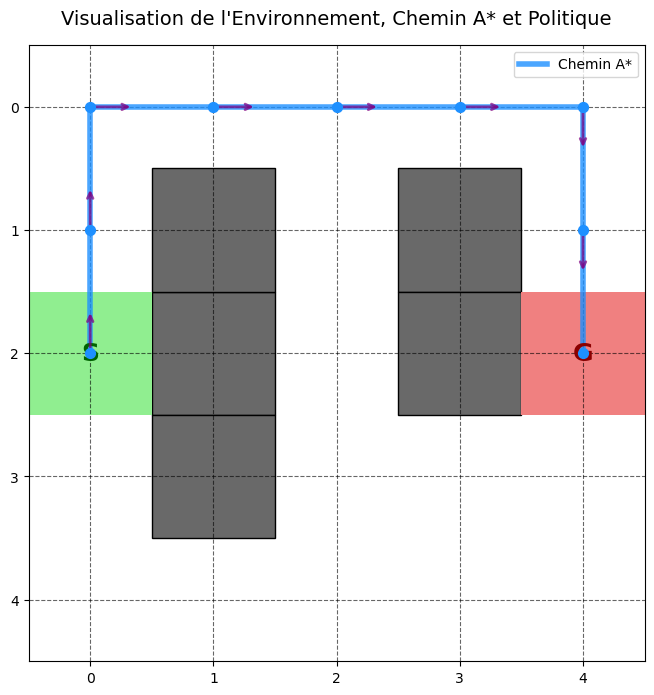

In [82]:
# On s'assure d'avoir calculé le chemin et la politique avant d'afficher
came_from_astar, _, _ = run_search(grid, start_node, goal_node, algorithm="astar")
chemin_astar = reconstruct_path(came_from_astar, start_node, goal_node)
politique_astar = extract_policy(came_from_astar, goal_node)

# Appel de notre super fonction de visualisation
visualize_environment(grid, start_node, goal_node, path=chemin_astar, policy=politique_astar)

#  Expérience E.2 : Impact du taux d’erreur

- **Objectif** : Étudier comment différents **taux d’erreur (1% à 40%)** affectent le **temps moyen pour atteindre l’objectif**.  
- **Méthode** :  
  1. On utilise la **politique optimale A\***.  
  2. Pour chaque taux d’erreur, on construit la **matrice de Markov** correspondante.  
  3. On calcule le **nombre moyen d’étapes** depuis le départ jusqu’au but.  
- **Visualisation** :  
  - Courbe du **temps moyen théorique** en fonction du taux d’erreur.  
  - Ligne horizontale indiquant le **chemin idéal A\*** sans déviation.  

Résultat : ce graphique montre **comment l’incertitude augmente la durée du parcours** et permet de comparer la robustesse de la politique.


--- Expérience E.2 : Impact du taux d'erreur sur le temps de parcours ---

--- Analyse Markovienne ---
Nombre d'états transitoires : 8
Nombre d'états absorbants : 12
Taux d'erreur 01% -> Temps moyen : 8.07 étapes

--- Analyse Markovienne ---
Nombre d'états transitoires : 8
Nombre d'états absorbants : 12
Taux d'erreur 05% -> Temps moyen : 8.37 étapes

--- Analyse Markovienne ---
Nombre d'états transitoires : 8
Nombre d'états absorbants : 12
Taux d'erreur 10% -> Temps moyen : 8.78 étapes

--- Analyse Markovienne ---
Nombre d'états transitoires : 8
Nombre d'états absorbants : 12
Taux d'erreur 15% -> Temps moyen : 9.23 étapes

--- Analyse Markovienne ---
Nombre d'états transitoires : 8
Nombre d'états absorbants : 12
Taux d'erreur 20% -> Temps moyen : 9.74 étapes

--- Analyse Markovienne ---
Nombre d'états transitoires : 8
Nombre d'états absorbants : 12
Taux d'erreur 25% -> Temps moyen : 10.32 étapes

--- Analyse Markovienne ---
Nombre d'états transitoires : 8
Nombre d'états absorbants : 1

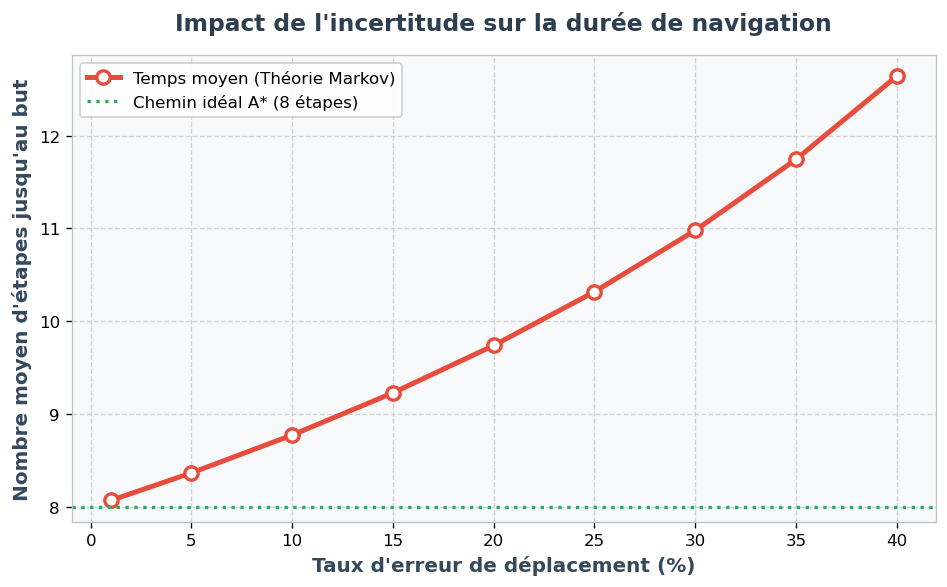

In [83]:
import matplotlib.pyplot as plt

print("\n--- Expérience E.2 : Impact du taux d'erreur sur le temps de parcours ---")

# Liste des taux d'erreur à tester (de 1% à 40%)
valeurs_epsilon = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
temps_moyens_theoriques = []

# On s'assure d'avoir la politique de base (A*)
came_from_astar, _, _ = run_search(grid, start_node, goal_node, algorithm="astar")
optimal_policy = extract_policy(came_from_astar, goal_node)

for eps in valeurs_epsilon:
    # 1. Construire la matrice P pour ce taux d'erreur spécifique
    P_exp, states_exp, _ = build_markov_matrix(grid, optimal_policy, goal_node, epsilon=eps)
    
    # 2. Analyser mathématiquement la chaîne
    analyse = analyze_absorbing_markov(P_exp, states_exp)
    
    if analyse:
        # 3. Extraire le résultat pour notre point de départ
        idx_depart = analyse["transient_states"].index(start_node)
        temps = analyse["expected_steps"][idx_depart]
        temps_moyens_theoriques.append(temps)
        print(f"Taux d'erreur {eps*100:02.0f}% -> Temps moyen : {temps:.2f} étapes")
    else:
        temps_moyens_theoriques.append(None) # En cas d'erreur de calcul

# --- Création du graphique professionnel ---

fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
ax.set_facecolor('#f8f9fa')
ax.grid(color='#bdc3c7', linestyle='--', linewidth=0.8, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('#bdc3c7')

# Tracer la courbe principale
pourcentages = [e * 100 for e in valeurs_epsilon]
ax.plot(pourcentages, temps_moyens_theoriques, color='#e74c3c', linewidth=3, marker='o', 
        markersize=8, markerfacecolor='white', markeredgewidth=2, label="Temps moyen (Théorie Markov)")

ax.set_title("Impact de l'incertitude sur la durée de navigation", fontsize=14, weight='bold', color='#2c3e50', pad=15)
ax.set_xlabel("Taux d'erreur de déplacement (%)", fontsize=12, color='#34495e', weight='bold')
ax.set_ylabel("Nombre moyen d'étapes jusqu'au but", fontsize=12, color='#34495e', weight='bold')

# Marquer le temps idéal (sans erreur) pour comparer
temps_ideal = len(reconstruct_path(came_from_astar, start_node, goal_node)) - 1
ax.axhline(y=temps_ideal, color='#27ae60', linestyle=':', linewidth=2, label=f"Chemin idéal A* ({temps_ideal} étapes)")

plt.legend(framealpha=0.9)
plt.tight_layout()
plt.show()